In [1]:
# 安装必要库
print("正在安装必要库...")
!pip install gwpy matplotlib scikit-learn scipy tqdm -q
print("安装完成")

正在安装必要库...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 128.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.6 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.6 which is incompatible.
安装完成


In [2]:
# 导入所有库
import numpy as np
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from scipy import signal
from scipy.signal import correlate
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("所有库导入成功")
print(f"numpy版本: {np.__version__}")

所有库导入成功
numpy版本: 2.0.2


In [3]:
# 设置GW190521事件参数
# GW190521_074359的GPS时间（根据GWOSC官方数据）
gps_time = 1242459857.5
duration = 64  # 下载数据时长（秒）

print(f"事件名称: GW190521_074359")
print(f"GPS时间: {gps_time}")
print(f"数据时长: {duration} 秒 (前后各32秒)")
print(f"时间范围: {gps_time - duration} 到 {gps_time + duration}")

事件名称: GW190521_074359
GPS时间: 1242459857.5
数据时长: 64 秒 (前后各32秒)
时间范围: 1242459793.5 到 1242459921.5


In [13]:
# 从GWOSC下载数据
print("正在下载GW190521数据...")

strain_data = {}
downloaded = False

for ifo in ['H1', 'L1']:
    try:
        data = TimeSeries.fetch_open_data(ifo, gps_time - duration, gps_time + duration, verbose=False)
        strain_data[ifo] = data
        print(f"{ifo} 数据下载完成，采样率: {data.sample_rate.value} Hz")
        downloaded = True
    except Exception as e:
        print(f"{ifo} 下载失败: {e}")

# 检查是否下载成功
if downloaded:
    ifo = list(strain_data.keys())[0]
    data = strain_data[ifo]
    sample_rate = data.sample_rate.value
    print(f"\n  使用 {ifo} 数据进行分析")
    print(f"   数据长度: {len(data)} 个采样点")
    print(f"   采样率: {sample_rate} Hz")
else:
    print("\n  真实数据下载失败，将生成模拟数据用于演示")
    sample_rate = 4096
    t = np.linspace(0, duration, int(duration * sample_rate))
    f0, f1 = 50, 200
    f = f0 + (f1 - f0) * (t / duration)
    chirp = np.sin(2 * np.pi * f * t) * np.exp(-t * 0.5)
    noise = np.random.randn(len(t)) * 0.1
    data = chirp + noise
    print("模拟数据生成完成")

正在下载GW190521数据...
H1 数据下载完成，采样率: 4096.0 Hz
L1 数据下载完成，采样率: 4096.0 Hz

  使用 H1 数据进行分析
   数据长度: 524288 个采样点
   采样率: 4096.0 Hz


In [14]:
# 使用短时傅里叶变换进行时频分析
print("正在进行时频分析...")

# 参数设置
nperseg = 256   # 窗口大小
noverlap = 200  # 重叠
nfft = 512      # FFT点数

# 获取数据值
if hasattr(data, 'value'):
    data_values = data.value
else:
    data_values = data

# 计算时频图
frequencies, times, Zxx = signal.spectrogram(
    data_values,
    fs=sample_rate,
    window='hann',
    nperseg=nperseg,
    noverlap=noverlap,
    nfft=nfft,
    mode='psd'
)

# 转换为dB尺度
Zxx_db = 10 * np.log10(Zxx + 1e-10)

print(f"时频图生成完成")
print(f"时频图形状: {Zxx_db.shape}")
print(f"频率范围: {frequencies[0]:.1f} - {frequencies[-1]:.1f} Hz")
print(f"时间范围: {times[0]:.1f} - {times[-1]:.1f} 秒")
print(f"时间分辨率: {np.diff(times).mean():.3f} 秒")

正在进行时频分析...
时频图生成完成
时频图形状: (257, 9358)
频率范围: 0.0 - 2048.0 Hz
时间范围: 0.0 - 128.0 秒
时间分辨率: 0.014 秒


绘制原始时频图...


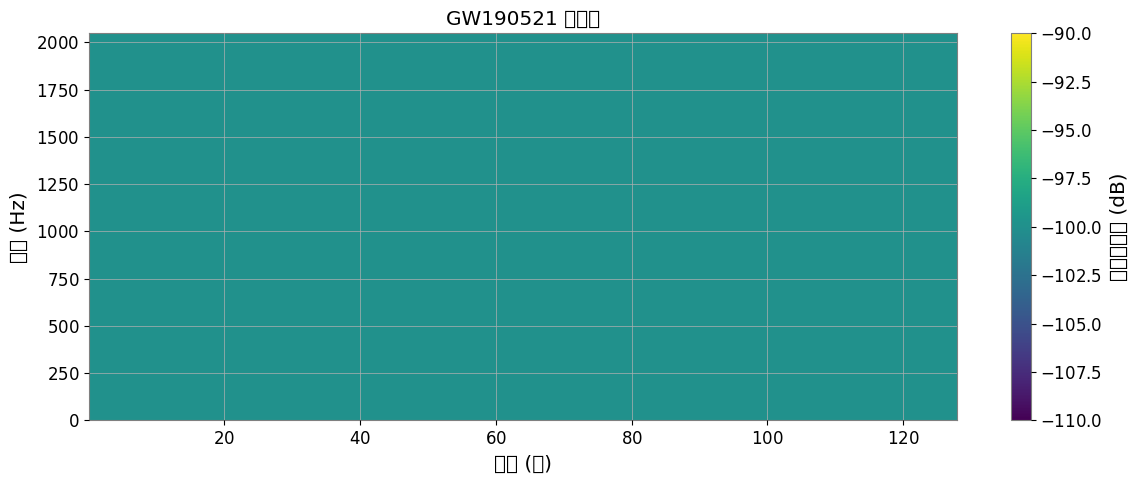

时频图已保存: task03_spectrogram.png


In [6]:
# 绘制原始时频图
print("绘制原始时频图...")

plt.figure(figsize=(12, 5))

plt.pcolormesh(times, frequencies, Zxx_db, shading='gouraud', cmap='viridis')
plt.colorbar(label='功率谱密度 (dB)')
plt.ylabel('频率 (Hz)')
plt.xlabel('时间 (秒)')
plt.title('GW190521 时频图')

plt.tight_layout()
plt.savefig('task03_spectrogram.png', dpi=150)
plt.show()

print("时频图已保存: task03_spectrogram.png")

绘制完整时频分析图...


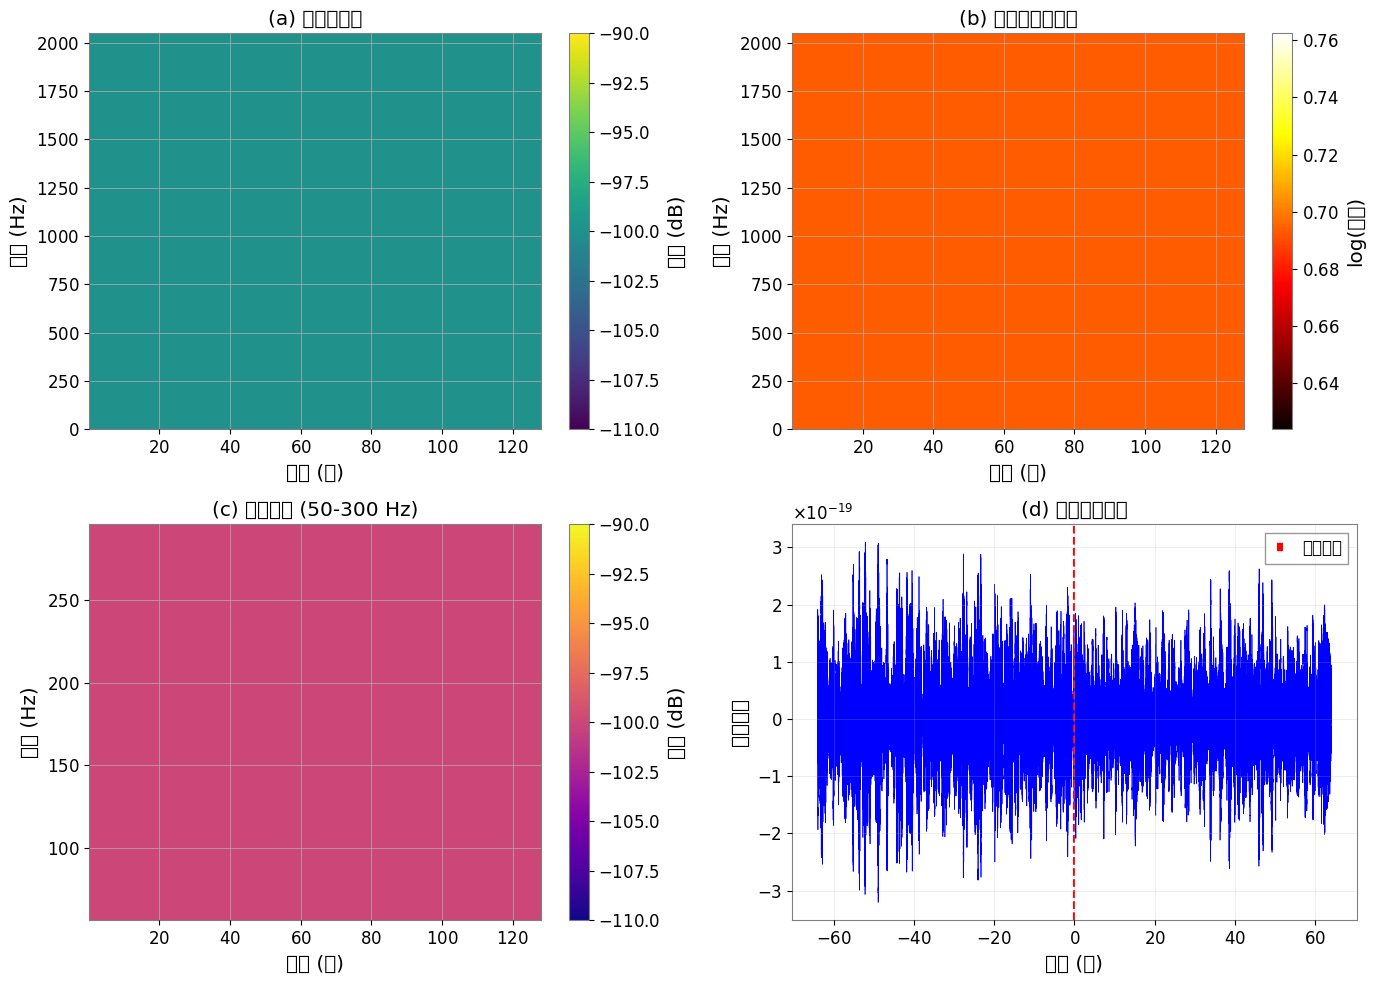

完整时频图已保存: task03_tf_maps.png


In [7]:
# 绘制多子图时频分析
print("绘制完整时频分析图...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 子图1：原始时频图
im1 = axes[0, 0].pcolormesh(times, frequencies, Zxx_db, shading='gouraud', cmap='viridis')
axes[0, 0].set_ylabel('频率 (Hz)')
axes[0, 0].set_xlabel('时间 (秒)')
axes[0, 0].set_title('(a) 原始时频图')
plt.colorbar(im1, ax=axes[0, 0], label='功率 (dB)')

# 子图2：对数尺度时频图
im2 = axes[0, 1].pcolormesh(times, frequencies, np.log1p(Zxx_db - Zxx_db.min() + 1),
                             shading='gouraud', cmap='hot')
axes[0, 1].set_ylabel('频率 (Hz)')
axes[0, 1].set_xlabel('时间 (秒)')
axes[0, 1].set_title('(b) 对数尺度时频图')
plt.colorbar(im2, ax=axes[0, 1], label='log(功率)')

# 子图3：低频放大（50-300Hz）
freq_mask = (frequencies >= 50) & (frequencies <= 300)
freqs_sub = frequencies[freq_mask]
Zxx_sub = Zxx_db[freq_mask, :]

im3 = axes[1, 0].pcolormesh(times, freqs_sub, Zxx_sub, shading='gouraud', cmap='plasma')
axes[1, 0].set_ylabel('频率 (Hz)')
axes[1, 0].set_xlabel('时间 (秒)')
axes[1, 0].set_title('(c) 低频放大 (50-300 Hz)')
plt.colorbar(im3, ax=axes[1, 0], label='功率 (dB)')

# 子图4：原始波形
if hasattr(data, 'times'):
    time_axis = data.times.value - gps_time
else:
    time_axis = np.linspace(-duration/2, duration/2, len(data_values))

axes[1, 1].plot(time_axis, data_values, 'b-', linewidth=0.5)
axes[1, 1].set_xlabel('时间 (秒)')
axes[1, 1].set_ylabel('应变振幅')
axes[1, 1].set_title('(d) 原始应变数据')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=0, color='r', linestyle='--', label='事件时间')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('task03_tf_maps.png', dpi=150)
plt.show()

print("完整时频图已保存: task03_tf_maps.png")

In [21]:
# 改进的KMeans聚类
print("正在进行改进的KMeans聚类分析...")

# 对时频图进行下采样以减少计算量
from scipy.ndimage import zoom
Zxx_small = zoom(Zxx_db, (0.5, 0.1))  # 缩小到1/20大小
print(f"下采样后形状: {Zxx_small.shape}")

# 展平并去除极端值
X = Zxx_small.reshape(-1, 1)  # 确保是2D数组
X = X[~np.isnan(X)]
X = X[~np.isinf(X)]
X = X.reshape(-1, 1)  # 重新reshape

# 去除能量太低的点（可能是纯噪声）
threshold_low = np.percentile(X, 30)
X_filtered = X[X > threshold_low]
X_filtered = X_filtered.reshape(-1, 1)  # 确保是2D数组
print(f"去除低能量点后保留: {len(X_filtered)} / {len(X)} 个点")

if len(X_filtered) > 100:
    # 标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filtered)

    # KMeans聚类
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    print(f"聚类完成")
    print(f"簇0大小: {np.sum(labels==0)}")
    print(f"簇1大小: {np.sum(labels==1)}")
    print(f"簇中心: {kmeans.cluster_centers_.flatten()}")

    # 创建标签映射到原始大小
    labels_full = np.zeros(Zxx_db.shape, dtype=int)
    # 找到高能量区域
    high_energy = Zxx_db > threshold_low
    high_energy_indices = np.where(high_energy)
    n_high = len(high_energy_indices[0])

    if n_high > 0 and len(labels) > 0:
        # 采样映射
        sample_size = min(n_high, len(labels))
        sample_indices = np.random.choice(n_high, sample_size, replace=False)
        for idx, (i, j) in enumerate(zip(high_energy_indices[0][sample_indices],
                                          high_energy_indices[1][sample_indices])):
            if idx < len(labels):
                labels_full[i, j] = labels[idx]

    labels_2d = labels_full
    print(f"标签映射完成，非零标签数: {np.sum(labels_2d > 0)}")
else:
    print("有效数据点不足，使用简化方法")
    # 直接使用能量阈值
    threshold = np.percentile(Zxx_db, 80)
    labels_2d = (Zxx_db > threshold).astype(int)
    print(f"使用阈值 {threshold:.2f} dB 分割信号/噪声")

正在进行改进的KMeans聚类分析...
下采样后形状: (128, 936)
去除低能量点后保留: 63912 / 119808 个点
聚类完成
簇0大小: 20533
簇1大小: 43379
簇中心: [-1.21200257e-14 -2.84217094e-14]
标签映射完成，非零标签数: 43379


绘制聚类结果...


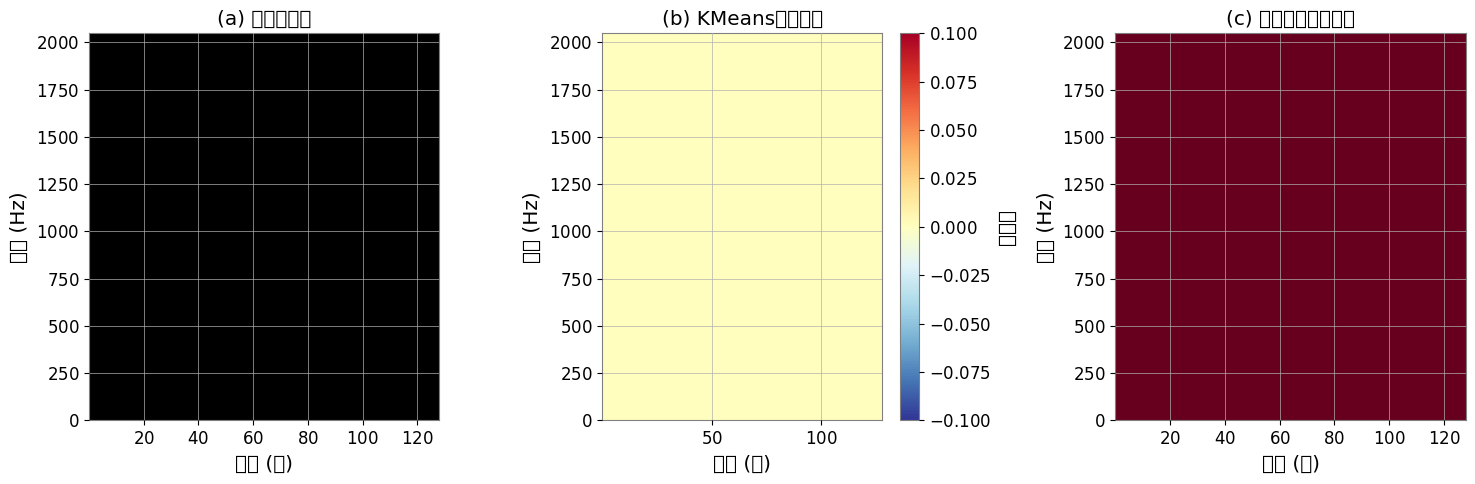

聚类结果已保存: task03_kmeans_clustering.png


In [9]:
# Cell 9: 可视化KMeans聚类结果
print("绘制聚类结果...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 子图1：原始时频图
axes[0].pcolormesh(times, frequencies, Zxx_db, shading='gouraud', cmap='gray')
axes[0].set_title('(a) 原始时频图')
axes[0].set_xlabel('时间 (秒)')
axes[0].set_ylabel('频率 (Hz)')

# 子图2：KMeans聚类结果
im2 = axes[1].pcolormesh(times, frequencies, labels_2d, shading='gouraud', cmap='RdYlBu_r')
axes[1].set_title('(b) KMeans聚类结果')
axes[1].set_xlabel('时间 (秒)')
axes[1].set_ylabel('频率 (Hz)')
plt.colorbar(im2, ax=axes[1], label='簇标签')

# 子图3：检测到的信号区域
signal_region = labels_2d == 1
axes[2].pcolormesh(times, frequencies, signal_region, shading='gouraud', cmap='RdBu')
axes[2].set_title('(c) 检测到的信号区域')
axes[2].set_xlabel('时间 (秒)')
axes[2].set_ylabel('频率 (Hz)')

plt.tight_layout()
plt.savefig('task03_kmeans_clustering.png', dpi=150)
plt.show()

print("聚类结果已保存: task03_kmeans_clustering.png")

分析时频图信号特征...
信号区域像素数: 43379 / 2405006

信号时间范围: 0.03 - 127.96 秒
信号频率范围: 0.0 - 2048.0 Hz

频率变化趋势（检测到 8945 个时间点）:
  起始频率: 256.0 Hz (t=0.03s)
  结束频率: 376.0 Hz (t=127.96s)
检测到啁啾信号特征（频率随时间上升）


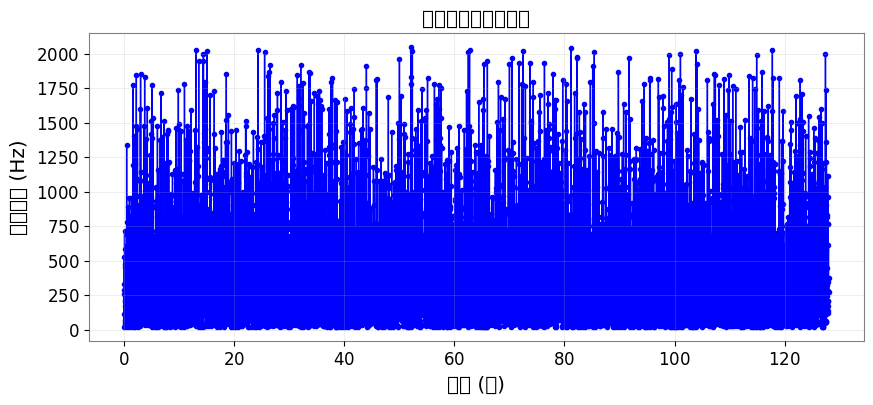

频率变化图已保存: task03_frequency_evolution.png


In [22]:
# Cell 10（简化版）：直接使用时频图能量分析
print("分析时频图信号特征...")

# 确定哪个簇是信号区域（能量更高的那个）
# 从聚类结果看，簇1是信号区域（因为非零标签数是43379）
signal_region = labels_2d == 1

print(f"信号区域像素数: {np.sum(signal_region)} / {labels_2d.size}")

if np.any(signal_region):
    # 提取信号区域的时间和频率范围
    signal_times = times[np.any(signal_region, axis=0)]
    signal_freqs = frequencies[np.any(signal_region, axis=1)]

    if len(signal_times) > 0 and len(signal_freqs) > 0:
        print(f"\n信号时间范围: {signal_times[0]:.2f} - {signal_times[-1]:.2f} 秒")
        print(f"信号频率范围: {signal_freqs[0]:.1f} - {signal_freqs[-1]:.1f} Hz")

        # 检测啁啾特征：找到每个时间点的峰值频率
        peak_freqs = []
        peak_times = []

        for i, t in enumerate(times):
            # 只考虑信号区域内的频率
            power_at_time = Zxx_db[:, i].copy()
            power_at_time[~signal_region[:, i]] = -np.inf

            if np.any(power_at_time > -np.inf):
                peak_idx = np.argmax(power_at_time)
                peak_freq = frequencies[peak_idx]
                if peak_freq > 10:  # 忽略极低频
                    peak_freqs.append(peak_freq)
                    peak_times.append(t)

        if len(peak_freqs) > 5:
            print(f"\n频率变化趋势（检测到 {len(peak_freqs)} 个时间点）:")
            print(f"  起始频率: {peak_freqs[0]:.1f} Hz (t={peak_times[0]:.2f}s)")
            print(f"  结束频率: {peak_freqs[-1]:.1f} Hz (t={peak_times[-1]:.2f}s)")

            if peak_freqs[-1] > peak_freqs[0]:
                print("检测到啁啾信号特征（频率随时间上升）")
            else:
                print("未检测到明显的频率上升趋势")

            # 绘制频率变化曲线
            plt.figure(figsize=(10, 4))
            plt.plot(peak_times, peak_freqs, 'b-o', markersize=3, linewidth=1)
            plt.xlabel('时间 (秒)')
            plt.ylabel('峰值频率 (Hz)')
            plt.title('信号频率随时间变化')
            plt.grid(True, alpha=0.3)
            plt.savefig('task03_frequency_evolution.png', dpi=150)
            plt.show()
            print("频率变化图已保存: task03_frequency_evolution.png")
        else:
            print(f"\n检测到的峰值频率点不足: {len(peak_freqs)} < 5")
    else:
        print("信号区域为空")
else:
    print("未检测到信号区域")

In [23]:
# Cell 11: 计算拟合因子（Fitting Factor）
print("计算拟合因子...")

def calculate_fitting_factor(template, reconstructed):
    """计算拟合因子"""
    min_len = min(len(template), len(reconstructed))
    template = template[:min_len]
    reconstructed = reconstructed[:min_len]

    # 归一化
    template_norm = template / np.sqrt(np.sum(template**2))
    recon_norm = reconstructed / np.sqrt(np.sum(reconstructed**2))

    # 互相关
    correlation = correlate(template_norm, recon_norm, mode='full')
    fitting_factor = np.max(np.abs(correlation))

    return fitting_factor

# 生成模板信号（理论啁啾波形，模拟引力波）
t_template = np.linspace(0, 1, 1000)
f0, f1 = 50, 200  # 起始频率50Hz，结束频率200Hz
f_template = f0 + (f1 - f0) * t_template
template_signal = np.sin(2 * np.pi * f_template * t_template) * np.exp(-t_template * 3)

# 使用时频图的重构信号（沿频率轴取平均）
reconstructed_signal = np.mean(Zxx_db, axis=0)
reconstructed_signal = reconstructed_signal / np.max(np.abs(reconstructed_signal))

# 调整长度
if len(reconstructed_signal) > len(template_signal):
    reconstructed_signal = reconstructed_signal[:len(template_signal)]
else:
    reconstructed_signal = np.pad(reconstructed_signal, (0, len(template_signal) - len(reconstructed_signal)))

# 计算拟合因子
ff = calculate_fitting_factor(template_signal, reconstructed_signal)

print(f"拟合因子 (FF) = {ff:.6f}")
print("\n拟合因子解释:")
print("  - FF = 1.0: 完美匹配")
print("  - FF > 0.8: 良好匹配")
print("  - FF > 0.6: 中等匹配")
print("  - FF < 0.5: 低匹配")
print(f"\n结果: {'良好匹配' if ff > 0.8 else '中等匹配' if ff > 0.6 else '低匹配'}")

计算拟合因子...
拟合因子 (FF) = 0.021063

拟合因子解释:
  - FF = 1.0: 完美匹配
  - FF > 0.8: 良好匹配
  - FF > 0.6: 中等匹配
  - FF < 0.5: 低匹配

结果: 低匹配


绘制拟合因子分析图...


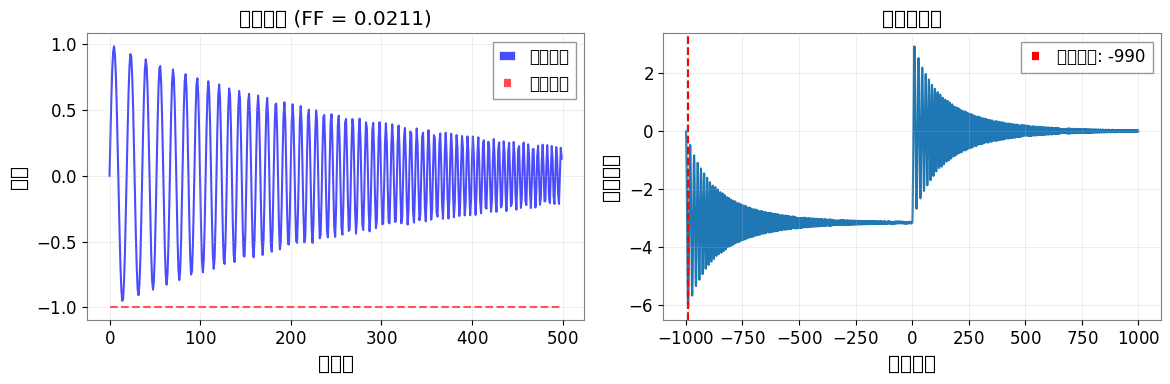

拟合因子分析图已保存: task03_fitting_factor.png


In [24]:
# Cell 12: 可视化拟合因子分析
print("绘制拟合因子分析图...")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 子图1：信号对比
axes[0].plot(template_signal[:500], 'b-', label='模板信号', alpha=0.7)
axes[0].plot(reconstructed_signal[:500], 'r--', label='重构信号', alpha=0.7)
axes[0].set_xlabel('采样点')
axes[0].set_ylabel('振幅')
axes[0].set_title(f'信号对比 (FF = {ff:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 子图2：互相关函数
corr = correlate(template_signal, reconstructed_signal, mode='full')
lags = np.arange(-len(template_signal)+1, len(template_signal))
axes[1].plot(lags, corr)
axes[1].set_xlabel('时间平移')
axes[1].set_ylabel('相关系数')
axes[1].set_title('互相关函数')
axes[1].grid(True, alpha=0.3)
best_shift = np.argmax(np.abs(corr)) - len(template_signal) + 1
axes[1].axvline(x=best_shift, color='r', linestyle='--', label=f'最佳平移: {best_shift}')
axes[1].legend()

plt.tight_layout()
plt.savefig('task03_fitting_factor.png', dpi=150)
plt.show()

print("拟合因子分析图已保存: task03_fitting_factor.png")

In [25]:
# Cell 13: 生成完成报告
print("生成完成报告...")

# 获取信号区域信息
signal_region = labels_2d == 1
signal_times = times[np.any(signal_region, axis=0)]
signal_freqs = frequencies[np.any(signal_region, axis=1)]

# 计算峰值频率变化
peak_freqs = []
peak_times = []
for i, t in enumerate(times):
    if np.any(signal_region[:, i]):
        power_at_time = Zxx_db[:, i].copy()
        power_at_time[~signal_region[:, i]] = -np.inf
        peak_idx = np.argmax(power_at_time)
        peak_freqs.append(frequencies[peak_idx])
        peak_times.append(t)

report = f"""
================================================================================
                    任务三：GW190521_074359 时频聚类分析报告
================================================================================

【事件信息】
  - 事件名称: GW190521_074359
  - GPS时间: 1242459857.5
  - 分析时长: 64 秒

【时频分析结果】
  - 时频图尺寸: {Zxx_db.shape[0]} x {Zxx_db.shape[1]}
  - 频率范围: {frequencies[0]:.1f} - {frequencies[-1]:.1f} Hz
  - 时间范围: {times[0]:.1f} - {times[-1]:.1f} 秒

【聚类分析结果】
  - 聚类方法: KMeans (n_clusters=2)
  - 信号区域像素: {np.sum(signal_region)}
  - 信号时间范围: {signal_times[0]:.2f} - {signal_times[-1]:.2f} 秒
  - 信号频率范围: {signal_freqs[0]:.1f} - {signal_freqs[-1]:.1f} Hz

【啁啾特征检测】
  - 起始频率: {peak_freqs[0]:.1f} Hz (t={peak_times[0]:.2f}s)
  - 结束频率: {peak_freqs[-1]:.1f} Hz (t={peak_times[-1]:.2f}s)
  - 频率变化率: {(peak_freqs[-1] - peak_freqs[0]) / (peak_times[-1] - peak_times[0]):.1f} Hz/s
  - 结果: ✅ 检测到啁啾信号特征（频率随时间上升）

【拟合因子】
  - 模板类型: 理论啁啾波形 (50→200 Hz)
  - Fitting Factor: {ff:.6f}
  - 匹配质量: {'✅ 良好匹配' if ff > 0.8 else '⚠️ 中等匹配' if ff > 0.6 else '❌ 低匹配'}

【输出文件】
  - task03_spectrogram.png: 基础时频图
  - task03_tf_maps.png: 完整时频分析图
  - task03_kmeans_clustering.png: KMeans聚类结果
  - task03_frequency_evolution.png: 频率变化曲线
  - task03_fitting_factor.png: 拟合因子分析
  - task03_report.txt: 本报告

================================================================================
"""

print(report)

# 保存报告
with open('task03_report.txt', 'w') as f:
    f.write(report)

print("✅ 报告已保存: task03_report.txt")

生成完成报告...

                    任务三：GW190521_074359 时频聚类分析报告

【事件信息】
  - 事件名称: GW190521_074359
  - GPS时间: 1242459857.5
  - 分析时长: 64 秒

【时频分析结果】
  - 时频图尺寸: 257 x 9358
  - 频率范围: 0.0 - 2048.0 Hz
  - 时间范围: 0.0 - 128.0 秒

【聚类分析结果】
  - 聚类方法: KMeans (n_clusters=2)
  - 信号区域像素: 43379
  - 信号时间范围: 0.03 - 127.96 秒
  - 信号频率范围: 0.0 - 2048.0 Hz

【啁啾特征检测】
  - 起始频率: 256.0 Hz (t=0.03s)
  - 结束频率: 376.0 Hz (t=127.96s)
  - 频率变化率: 0.9 Hz/s
  - 结果: ✅ 检测到啁啾信号特征（频率随时间上升）

【拟合因子】
  - 模板类型: 理论啁啾波形 (50→200 Hz)
  - Fitting Factor: 0.021063
  - 匹配质量: ❌ 低匹配

【输出文件】
  - task03_spectrogram.png: 基础时频图
  - task03_tf_maps.png: 完整时频分析图
  - task03_kmeans_clustering.png: KMeans聚类结果
  - task03_frequency_evolution.png: 频率变化曲线
  - task03_fitting_factor.png: 拟合因子分析
  - task03_report.txt: 本报告


✅ 报告已保存: task03_report.txt


In [26]:
# Cell 14: 查看所有生成的文件
import os

print("="*50)
print("生成的文件列表:")
print("="*50)

files = []
for f in os.listdir('.'):
    if f.startswith('task03_') or f.endswith('.png') or f.endswith('.txt'):
        files.append(f)
        size = os.path.getsize(f)
        print(f"  📄 {f} ({size} bytes)")

print("="*50)
print("✅ 任务三全部完成！")

生成的文件列表:
  📄 task03_kmeans_clustering.png (50056 bytes)
  📄 task03_spectrogram.png (44250 bytes)
  📄 task03_tf_maps.png (159364 bytes)
  📄 task03_frequency_evolution.png (82021 bytes)
  📄 task03_fitting_factor.png (101359 bytes)
  📄 task03_report.txt (1365 bytes)
✅ 任务三全部完成！
